In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
df = pd.read_csv("ai_job_dataset.csv")


### Understand the dataset

In [22]:
df.shape

(15000, 19)

In [23]:
df.head(3)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [25]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [26]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

###  Salary Distribution 

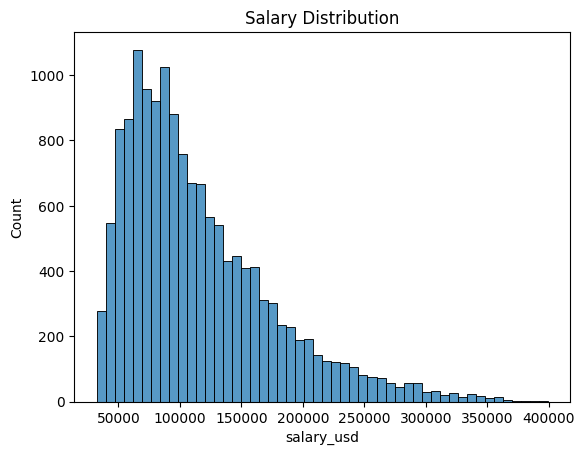

In [27]:
sns.histplot(df["salary_usd"], bins=50)
plt.title("Salary Distribution")
plt.show()

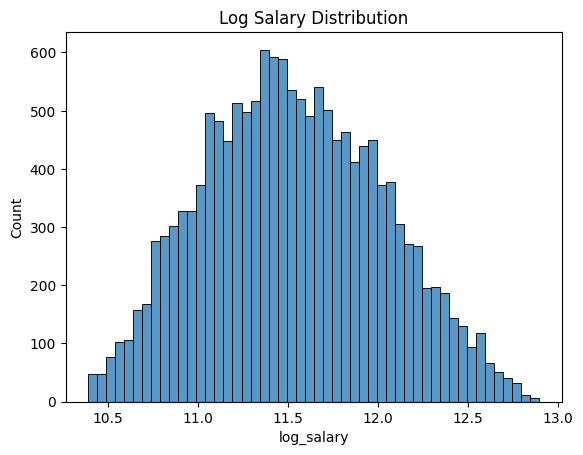

In [28]:
df["log_salary"] = np.log1p(df["salary_usd"])
sns.histplot(df["log_salary"], bins=50)
plt.title("Log Salary Distribution")
plt.show()

  ### feature engineering 

In [29]:
# Encode Categorical Variables

categorical_cols = ["experience_level", "employment_type", "company_size"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [30]:
# 

top_titles = df["job_title"].value_counts().nlargest(10).index
df["job_title"] = df["job_title"].apply(lambda x: x if x in top_titles else "Other")
df = pd.get_dummies(df, columns=["job_title"], drop_first=True)

In [31]:
df["remote_experience"] = df["remote_ratio"] * df["years_experience"]

### Train the test split

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(["salary_usd", "log_salary"], axis=1)
y = df["log_salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### feature scaling

In [35]:
X_train = X_train.select_dtypes(include=['int64','float64'])
X_test = X_test.select_dtypes(include=['int64','float64'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regresssion

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred_lin = lin_model.predict(X_test_scaled)
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("Linear R2:", r2_score(y_test, y_pred_lin))

Linear RMSE: 0.31949003151120986
Linear R2: 0.584750728709523


### Polynomial regression

In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("lin", LinearRegression())])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

print("Polynomial RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial RMSE: 0.3009634091005867


In [40]:
# compare the train vs test

train_pred_poly = poly_model.predict(X_train)
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_poly)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Train RMSE: 0.3069139920274669
Test RMSE: 0.3009634091005867


### Ridge Regression

In [43]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)


print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge RMSE: 0.319490959165556


In [44]:
from sklearn.model_selection import GridSearchCV


params = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(Ridge(), params, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best alpha:", grid.best_params_)

Best alpha: {'alpha': 10}


### Lesso

In [46]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

non_zero = np.sum(lasso.coef_ != 0)
print("Non-zero coefficients:", non_zero)

Non-zero coefficients: 1


### learning curves

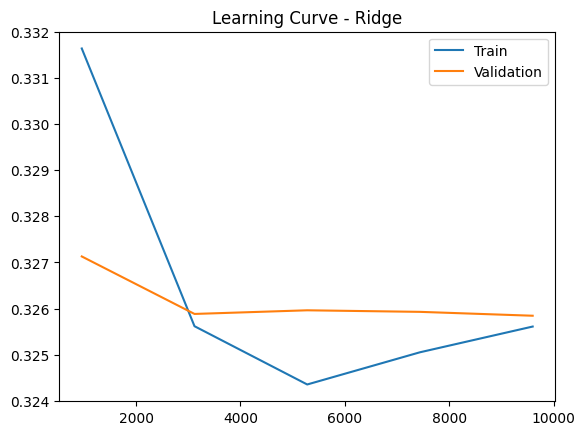

In [48]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    ridge, X_train_scaled, y_train,
    cv=5,
    scoring="neg_mean_squared_error")

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.plot(train_sizes, train_rmse, label="Train")
plt.plot(train_sizes, val_rmse, label="Validation")
plt.legend()

plt.title("Learning Curve - Ridge")
plt.show()

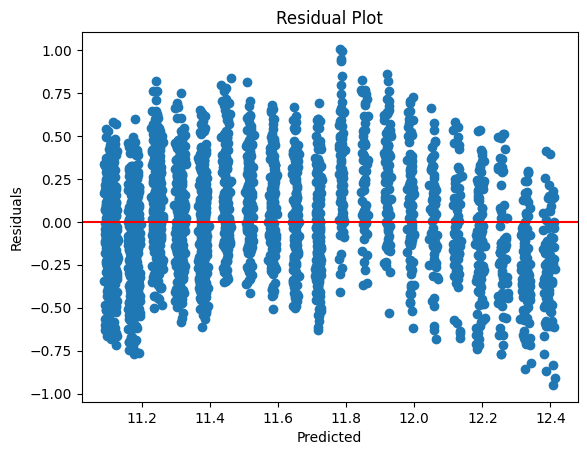

In [49]:
# analysis

residuals = y_test - y_pred_ridge

plt.scatter(y_pred_ridge, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [50]:
## model comparision

results = {
    "Linear": np.sqrt(mean_squared_error(y_test, y_pred_lin)),
    "Polynomial": np.sqrt(mean_squared_error(y_test, y_pred_poly)),
    "Ridge": np.sqrt(mean_squared_error(y_test, y_pred_ridge))}

print(results)

{'Linear': np.float64(0.31949003151120986), 'Polynomial': np.float64(0.3009634091005867), 'Ridge': np.float64(0.319490959165556)}
